# Phase 6: Portfolio Risk Simulation

**Project:** Credit Default Risk Modeling  
**Phase:** 6 — Expected Loss, Monte Carlo Simulation, Value at Risk

---

## What Are We Building?

This is what **risk teams at JPMorgan, Goldman Sachs, and Deutsche Bank** actually do.

We simulate the **loss distribution of a loan portfolio** and answer:
- What is our **Expected Loss** (EL)?
- What is our **worst-case loss** at 95% and 99% confidence? (VaR)
- How much **capital** should the bank hold as a buffer? (Economic Capital)

---

## The Basel II Framework

$$\text{Expected Loss} = PD \times LGD \times EAD$$

Where:
- **PD** — Probability of Default (from our scorecard model)
- **LGD** — Loss Given Default (% of loan lost if default occurs)
- **EAD** — Exposure at Default (outstanding loan amount)

$$\text{Unexpected Loss (VaR)} = \text{Percentile}_{99\%}(\text{Simulated Portfolio Loss}) - EL$$

$$\text{Economic Capital} = VaR_{99\%} - EL$$

---

## Monte Carlo Simulation

For each simulation run:
1. Each loan defaults independently with probability = PD
2. If default: loss = LGD × EAD
3. Sum losses across all loans = portfolio loss for that scenario
4. Repeat 10,000 times → full loss distribution

This gives us the **empirical loss distribution** — no assumptions about normality required.

## 1 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

# Simulation parameters
N_SIMULATIONS = 10_000   # Monte Carlo iterations
LGD_MEAN      = 0.45     # avg Loss Given Default (45% — Basel II standard)
LGD_STD       = 0.10     # LGD uncertainty
CONFIDENCE_95 = 0.95
CONFIDENCE_99 = 0.99

print(f'Monte Carlo Simulations : {N_SIMULATIONS:,}')
print(f'LGD Mean                : {LGD_MEAN*100:.0f}%')
print(f'LGD Std Dev             : {LGD_STD*100:.0f}%')
print(f'VaR Confidence Levels   : {CONFIDENCE_95*100:.0f}% and {CONFIDENCE_99*100:.0f}%')
print('Libraries loaded successfully.')

Monte Carlo Simulations : 10,000
LGD Mean                : 45%
LGD Std Dev             : 10%
VaR Confidence Levels   : 95% and 99%
Libraries loaded successfully.


## 2 Load Data & Build PD Model

In [3]:
data = pd.read_csv('/home/vidit/Public/Project/Customer Churn Prediction/Data/german_credit_data.csv')

column_mapping = {
    'laufkont':'checking_account', 'laufzeit':'duration_months',
    'moral':'credit_history',      'verw':'purpose',
    'hoehe':'credit_amount',       'sparkont':'savings_account',
    'beszeit':'employment_years',  'rate':'installment_rate',
    'famges':'personal_status',    'buerge':'other_debtors',
    'wohnzeit':'residence_years',  'verm':'property',
    'alter':'age',                 'weitkred':'other_installments',
    'wohn':'housing',              'bishkred':'existing_credits',
    'beruf':'job',                 'pers':'dependents',
    'telef':'telephone',           'gastarb':'foreign_worker',
    'kredit':'target'
}
data.rename(columns=column_mapping, inplace=True)

raw_vals = sorted(data['target'].unique())
if set(raw_vals) == {1, 2}:
    data['target'] = data['target'].map({1: 0, 2: 1})
elif set(raw_vals) == {0, 1}:
    data['target'] = data['target'].map({1: 0, 0: 1})

numeric_selected     = ['duration_months', 'credit_amount', 'age', 'installment_rate']
categorical_selected = [
    'checking_account', 'credit_history', 'purpose', 'savings_account',
    'employment_years', 'personal_status', 'other_debtors', 'property',
    'other_installments', 'housing', 'foreign_worker'
]
selected_features = numeric_selected + categorical_selected

print(f'Shape: {data.shape} | Default Rate: {data["target"].mean()*100:.1f}%')
print('Data ready for modeling.')

Shape: (1000, 21) | Default Rate: 30.0%
Data ready for modeling.


In [4]:
# WoE encoding
def compute_woe_iv(df, feature, target, bins=10, is_numeric=True):
    df = df[[feature, target]].copy()
    total_events     = df[target].sum()
    total_non_events = len(df) - total_events
    df['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop') if is_numeric else df[feature]
    grouped = df.groupby('bin', observed=True)[target].agg(
        Events='sum', Total='count').reset_index()
    grouped['NonEvents']      = grouped['Total'] - grouped['Events']
    eps = 0.5
    grouped['pct_Events']    = (grouped['Events']    + eps) / (total_events     + eps)
    grouped['pct_NonEvents'] = (grouped['NonEvents'] + eps) / (total_non_events + eps)
    grouped['WoE']           = np.log(grouped['pct_Events'] / grouped['pct_NonEvents'])
    grouped['IV']            = (grouped['pct_Events'] - grouped['pct_NonEvents']) * grouped['WoE']
    grouped['Default_Rate']  = grouped['Events'] / grouped['Total']
    return grouped[['bin','Total','Events','NonEvents','Default_Rate','WoE','IV']].round(4), round(grouped['IV'].sum(), 4)


df_encoded = data.copy()
woe_maps   = {}

for feat in selected_features:
    is_num = feat in numeric_selected
    try:
        woe_df, _ = compute_woe_iv(data, feat, 'target', bins=10, is_numeric=is_num)
        if is_num:
            df_encoded[f'{feat}_bin'] = pd.qcut(data[feat], q=10, duplicates='drop')
            woe_map = woe_df.set_index('bin')['WoE'].to_dict()
            df_encoded[f'{feat}_woe'] = df_encoded[f'{feat}_bin'].map(woe_map)
            df_encoded.drop(columns=[f'{feat}_bin'], inplace=True)
        else:
            woe_map = woe_df.set_index('bin')['WoE'].to_dict()
            df_encoded[f'{feat}_woe'] = data[feat].map(woe_map)
        woe_maps[feat] = woe_map
    except Exception as e:
        print(f'  Skipped {feat}: {e}')

woe_cols = [f'{f}_woe' for f in selected_features if f'{f}_woe' in df_encoded.columns]

# Fit logistic regression
X = df_encoded[woe_cols].dropna()
y = df_encoded.loc[X.index, 'target']
X_sm = sm.add_constant(X)
lr   = sm.Logit(y, X_sm).fit(method='newton', maxiter=100, disp=False)

# PD for every applicant
log_odds = X_sm @ lr.params
pd_scores = (1 / (1 + np.exp(-log_odds))).values

print(f'PD model fitted successfully.')
print(f'Mean PD : {pd_scores.mean()*100:.2f}%')
print(f'Min PD  : {pd_scores.min()*100:.2f}%')
print(f'Max PD  : {pd_scores.max()*100:.2f}%')

PD model fitted successfully.
Mean PD : 30.00%
Min PD  : 0.40%
Max PD  : 94.21%


## 3 Build the Loan Portfolio

We use `credit_amount` as EAD (Exposure at Default) — the outstanding loan balance.

In [5]:
portfolio = data.loc[X.index, ['credit_amount', 'target']].copy()
portfolio['PD']  = pd_scores
portfolio['EAD'] = portfolio['credit_amount']   # DM (Deutsche Marks)
portfolio['LGD'] = LGD_MEAN                     # constant for now; stochastic in simulation
portfolio['EL']  = portfolio['PD'] * portfolio['LGD'] * portfolio['EAD']

# Portfolio summary
total_exposure = portfolio['EAD'].sum()
total_el       = portfolio['EL'].sum()
el_rate        = total_el / total_exposure

print('=== Portfolio Summary ===')
print(f'Number of Loans         : {len(portfolio):,}')
print(f'Total Exposure (EAD)    : DM {total_exposure:,.0f}')
print(f'Average Loan Size       : DM {portfolio["EAD"].mean():,.0f}')
print(f'Average PD              : {portfolio["PD"].mean()*100:.2f}%')
print(f'LGD (assumed)           : {LGD_MEAN*100:.0f}%')
print(f'Total Expected Loss (EL): DM {total_el:,.0f}')
print(f'EL as % of Portfolio    : {el_rate*100:.2f}%')
print()
print('Top 5 Highest-Risk Loans:')
print(portfolio.nlargest(5, 'EL')[['EAD','PD','LGD','EL']].round(2).to_string())

=== Portfolio Summary ===
Number of Loans         : 1,000
Total Exposure (EAD)    : DM 3,271,248
Average Loan Size       : DM 3,271
Average PD              : 30.00%
LGD (assumed)           : 45%
Total Expected Loss (EL): DM 532,844
EL as % of Portfolio    : 16.29%

Top 5 Highest-Risk Loans:
       EAD    PD   LGD       EL
962  15945  0.92  0.45  6606.89
976  18424  0.78  0.45  6500.01
645  15857  0.91  0.45  6474.87
847  14782  0.94  0.45  6267.06
929  14421  0.89  0.45  5763.25


## 4 Portfolio Risk Visualization

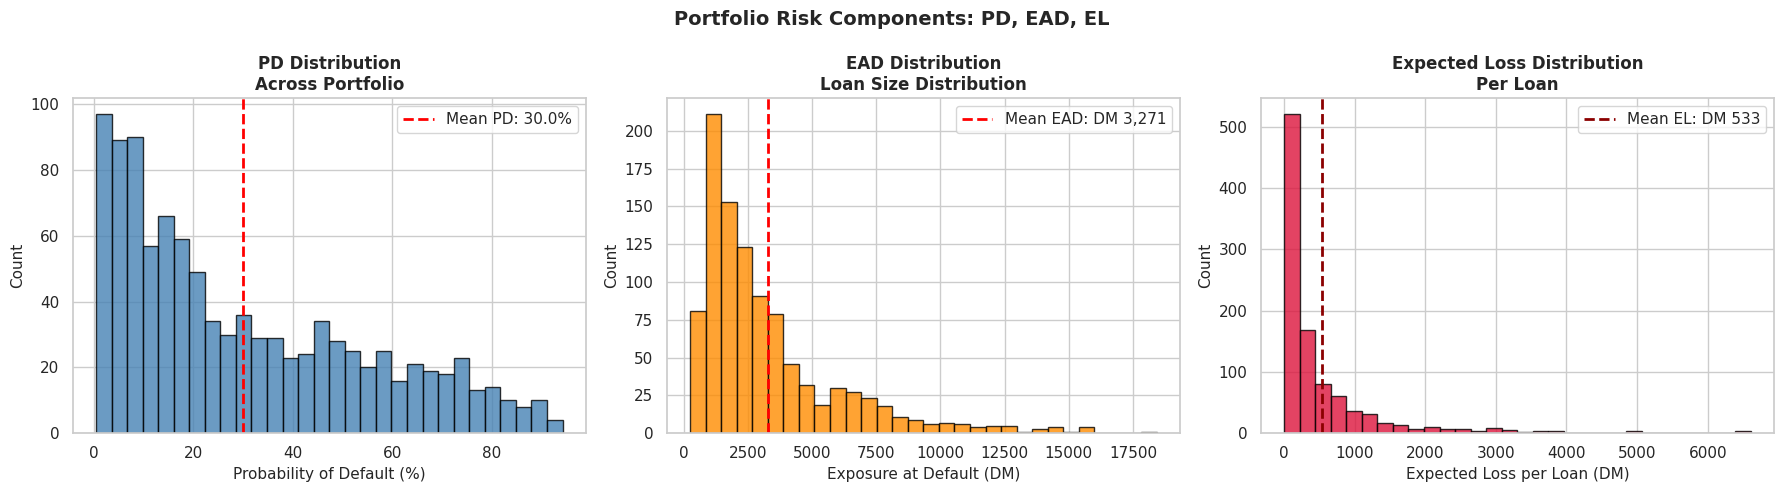

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PD distribution
axes[0].hist(portfolio['PD']*100, bins=30, color='steelblue',
             edgecolor='black', alpha=0.8)
axes[0].axvline(portfolio['PD'].mean()*100, color='red', linestyle='--',
                linewidth=2, label=f'Mean PD: {portfolio["PD"].mean()*100:.1f}%')
axes[0].set_xlabel('Probability of Default (%)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('PD Distribution\nAcross Portfolio', fontsize=12, fontweight='bold')
axes[0].legend()

# EAD distribution
axes[1].hist(portfolio['EAD'], bins=30, color='darkorange',
             edgecolor='black', alpha=0.8)
axes[1].axvline(portfolio['EAD'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean EAD: DM {portfolio["EAD"].mean():,.0f}')
axes[1].set_xlabel('Exposure at Default (DM)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('EAD Distribution\nLoan Size Distribution', fontsize=12, fontweight='bold')
axes[1].legend()

# EL distribution
axes[2].hist(portfolio['EL'], bins=30, color='crimson',
             edgecolor='black', alpha=0.8)
axes[2].axvline(portfolio['EL'].mean(), color='darkred', linestyle='--',
                linewidth=2, label=f'Mean EL: DM {portfolio["EL"].mean():,.0f}')
axes[2].set_xlabel('Expected Loss per Loan (DM)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_title('Expected Loss Distribution\nPer Loan', fontsize=12, fontweight='bold')
axes[2].legend()

plt.suptitle('Portfolio Risk Components: PD, EAD, EL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 Monte Carlo Simulation — Portfolio Loss Distribution

We simulate 10,000 possible portfolio outcomes.

In each simulation:
- Each loan defaults with its individual PD probability
- LGD is drawn from a Beta distribution (stochastic, not fixed)
- Portfolio loss = sum of individual loan losses

In [7]:
print(f'Running {N_SIMULATIONS:,} Monte Carlo simulations...')
print('This may take 10–20 seconds...\n')

n_loans = len(portfolio)
pd_arr  = portfolio['PD'].values
ead_arr = portfolio['EAD'].values

# Beta distribution parameters for stochastic LGD
# Mean = LGD_MEAN, Variance = LGD_STD^2
lgd_alpha = LGD_MEAN * ((LGD_MEAN * (1 - LGD_MEAN)) / LGD_STD**2 - 1)
lgd_beta  = (1 - LGD_MEAN) * ((LGD_MEAN * (1 - LGD_MEAN)) / LGD_STD**2 - 1)

print(f'LGD Beta distribution: α={lgd_alpha:.2f}, β={lgd_beta:.2f}')
print(f'LGD Mean={LGD_MEAN:.2f}, Std={LGD_STD:.2f}\n')

# Vectorized Monte Carlo
# Shape: (N_SIMULATIONS, n_loans)
uniform_draws = np.random.uniform(0, 1, size=(N_SIMULATIONS, n_loans))
default_matrix = (uniform_draws < pd_arr).astype(float)   # 1 if default

# Stochastic LGD: different LGD per loan per simulation
lgd_matrix = np.random.beta(lgd_alpha, lgd_beta, size=(N_SIMULATIONS, n_loans))

# Loss per loan per simulation
loss_matrix = default_matrix * lgd_matrix * ead_arr

# Portfolio loss per simulation (sum across loans)
portfolio_losses = loss_matrix.sum(axis=1)

print(f'Simulation complete | Sample Portfolio Losses:')
print(f'Mean simulated loss : DM {portfolio_losses.mean():,.0f}')
print(f'Std of losses       : DM {portfolio_losses.std():,.0f}')
print(f'Min simulated loss  : DM {portfolio_losses.min():,.0f}')
print(f'Max simulated loss  : DM {portfolio_losses.max():,.0f}')

Running 10,000 Monte Carlo simulations...
This may take 10–20 seconds...

LGD Beta distribution: α=10.69, β=13.06
LGD Mean=0.45, Std=0.10

Simulation complete | Sample Portfolio Losses:
Mean simulated loss : DM 533,008
Std of losses       : DM 26,535
Min simulated loss  : DM 421,113
Max simulated loss  : DM 647,299


## 6 Value at Risk (VaR) & Economic Capital

In [8]:
# Key risk metrics
el_simulated   = portfolio_losses.mean()
var_95         = np.percentile(portfolio_losses, 95)
var_99         = np.percentile(portfolio_losses, 99)
cvar_95        = portfolio_losses[portfolio_losses >= var_95].mean()   # Expected Shortfall
cvar_99        = portfolio_losses[portfolio_losses >= var_99].mean()
ec_95          = var_95  - el_simulated   # Economic Capital at 95%
ec_99          = var_99  - el_simulated   # Economic Capital at 99%
loss_std       = portfolio_losses.std()

print('=' * 65)
print('PORTFOLIO RISK METRICS — MONTE CARLO RESULTS')
print('=' * 65)
print(f'\n Loss Statistics:')
print(f'   Expected Loss (EL)      : DM {el_simulated:>12,.0f}  ({el_simulated/total_exposure*100:.2f}% of portfolio)')
print(f'   Loss Std Deviation      : DM {loss_std:>12,.0f}')
print(f'\n Value at Risk (VaR):')
print(f'   VaR @ 95% confidence    : DM {var_95:>12,.0f}  ({var_95/total_exposure*100:.2f}% of portfolio)')
print(f'   VaR @ 99% confidence    : DM {var_99:>12,.0f}  ({var_99/total_exposure*100:.2f}% of portfolio)')
print(f'\n Expected Shortfall (CVaR):')
print(f'   CVaR @ 95%              : DM {cvar_95:>12,.0f}  ({cvar_95/total_exposure*100:.2f}% of portfolio)')
print(f'   CVaR @ 99%              : DM {cvar_99:>12,.0f}  ({cvar_99/total_exposure*100:.2f}% of portfolio)')
print(f'\n Economic Capital (Basel II):')
print(f'   EC @ 95% (VaR - EL)     : DM {ec_95:>12,.0f}  ({ec_95/total_exposure*100:.2f}% of portfolio)')
print(f'   EC @ 99% (VaR - EL)     : DM {ec_99:>12,.0f}  ({ec_99/total_exposure*100:.2f}% of portfolio)')
print(f'\n Interpretation:')
print(f'   The bank should expect to lose DM {el_simulated:,.0f} on average.')
print(f'   In 1 out of 100 scenarios, losses will exceed DM {var_99:,.0f}.')
print(f'   To be 99% safe, hold DM {ec_99:,.0f} as capital buffer.')

PORTFOLIO RISK METRICS — MONTE CARLO RESULTS

 Loss Statistics:
   Expected Loss (EL)      : DM      533,008  (16.29% of portfolio)
   Loss Std Deviation      : DM       26,535

 Value at Risk (VaR):
   VaR @ 95% confidence    : DM      576,204  (17.61% of portfolio)
   VaR @ 99% confidence    : DM      594,462  (18.17% of portfolio)

 Expected Shortfall (CVaR):
   CVaR @ 95%              : DM      587,796  (17.97% of portfolio)
   CVaR @ 99%              : DM      603,159  (18.44% of portfolio)

 Economic Capital (Basel II):
   EC @ 95% (VaR - EL)     : DM       43,196  (1.32% of portfolio)
   EC @ 99% (VaR - EL)     : DM       61,454  (1.88% of portfolio)

 Interpretation:
   The bank should expect to lose DM 533,008 on average.
   In 1 out of 100 scenarios, losses will exceed DM 594,462.
   To be 99% safe, hold DM 61,454 as capital buffer.


## 7 Loss Distribution Plot — The Key Chart

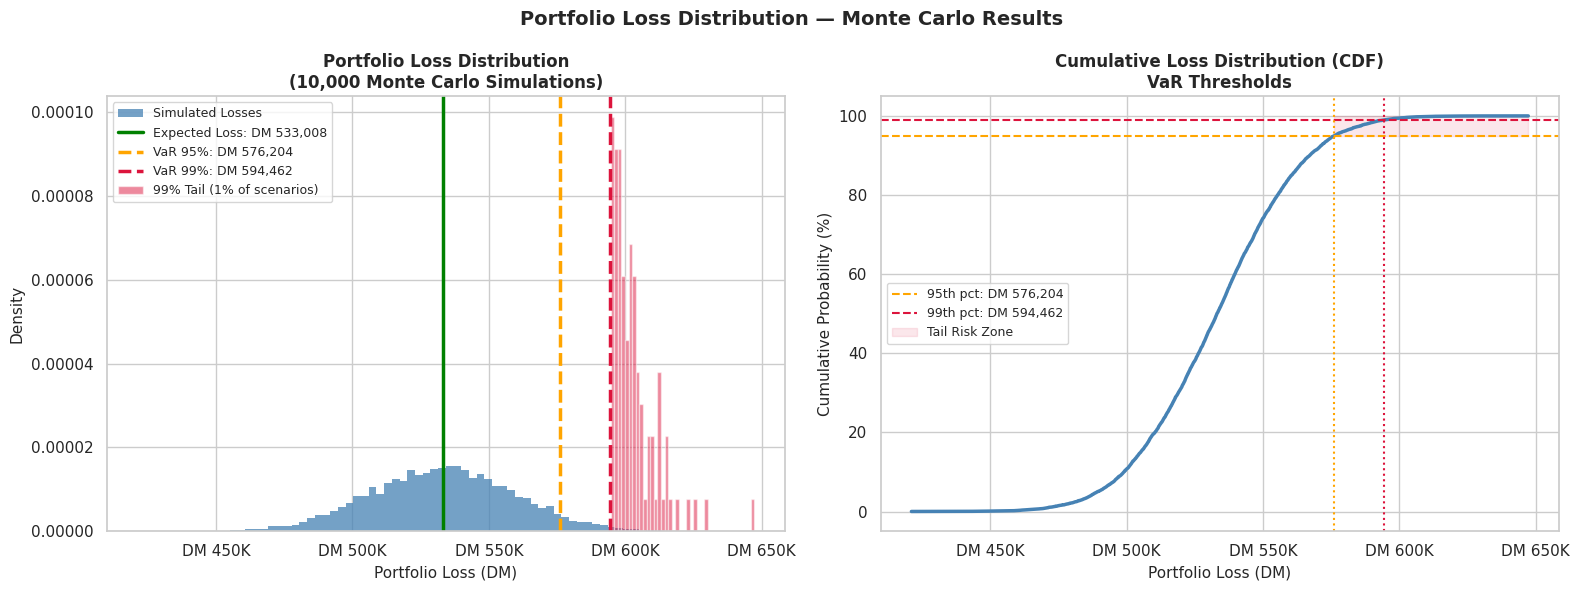

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss distribution with VaR lines
axes[0].hist(portfolio_losses, bins=80, color='steelblue',
             edgecolor='none', alpha=0.75, density=True, label='Simulated Losses')

# Shade tail regions
x_vals = np.sort(portfolio_losses)
axes[0].axvline(el_simulated, color='green', linewidth=2.5, linestyle='-',
                label=f'Expected Loss: DM {el_simulated:,.0f}')
axes[0].axvline(var_95, color='orange', linewidth=2.5, linestyle='--',
                label=f'VaR 95%: DM {var_95:,.0f}')
axes[0].axvline(var_99, color='crimson', linewidth=2.5, linestyle='--',
                label=f'VaR 99%: DM {var_99:,.0f}')

# Shade 99% tail
tail_losses = portfolio_losses[portfolio_losses >= var_99]
axes[0].hist(tail_losses, bins=40, color='crimson', alpha=0.5,
             density=True, label='99% Tail (1% of scenarios)')

axes[0].set_xlabel('Portfolio Loss (DM)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Portfolio Loss Distribution\n(10,000 Monte Carlo Simulations)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'DM {x/1000:.0f}K'))

# Cumulative loss distribution (CDF)
sorted_losses = np.sort(portfolio_losses)
cdf = np.arange(1, len(sorted_losses)+1) / len(sorted_losses)

axes[1].plot(sorted_losses, cdf*100, color='steelblue', linewidth=2.5)
axes[1].axhline(95, color='orange', linestyle='--', linewidth=1.5,
                label=f'95th pct: DM {var_95:,.0f}')
axes[1].axhline(99, color='crimson', linestyle='--', linewidth=1.5,
                label=f'99th pct: DM {var_99:,.0f}')
axes[1].axvline(var_95, color='orange', linestyle=':', linewidth=1.5)
axes[1].axvline(var_99, color='crimson', linestyle=':', linewidth=1.5)
axes[1].fill_betweenx([95, 100], var_95, sorted_losses.max(),
                       alpha=0.1, color='crimson', label='Tail Risk Zone')
axes[1].set_xlabel('Portfolio Loss (DM)', fontsize=11)
axes[1].set_ylabel('Cumulative Probability (%)', fontsize=11)
axes[1].set_title('Cumulative Loss Distribution (CDF)\nVaR Thresholds',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'DM {x/1000:.0f}K'))

plt.suptitle('Portfolio Loss Distribution — Monte Carlo Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 Sensitivity Analysis — How Does VaR Change with LGD?

LGD is often uncertain in practice. We test how sensitive our VaR is to LGD assumptions.

Running LGD sensitivity analysis...

=== LGD Sensitivity Analysis ===
 LGD     EL  VaR_95  VaR_99  EC_99
0.25 296423  324003  335081  38658
0.35 415034  449666  463587  48553
0.45 533181  576538  595250  62069
0.55 651614  703541  722795  71181
0.65 770033  830161  854124  84091
0.75 888183  958063  987612  99429


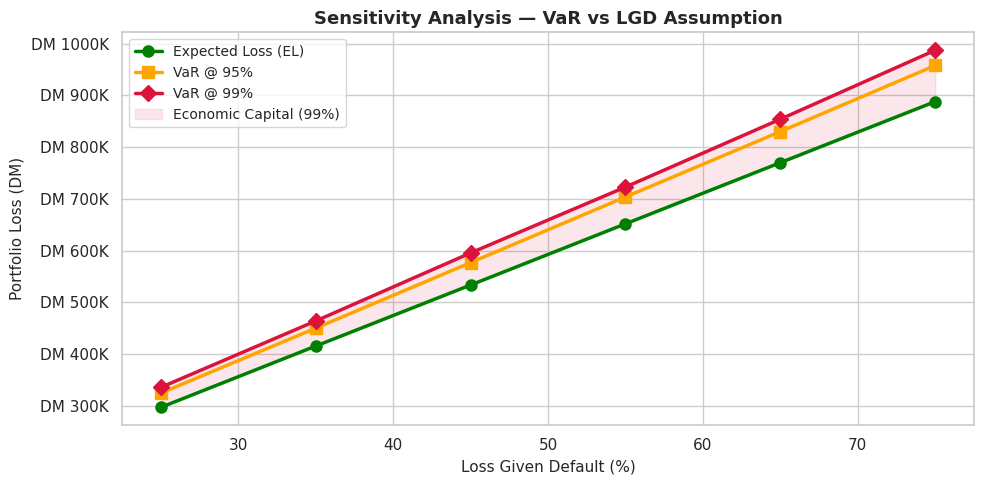

In [10]:
print('Running LGD sensitivity analysis...')

lgd_scenarios = [0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
sensitivity_results = []

for lgd in lgd_scenarios:
    # Recompute Beta params for this LGD
    lgd_a = lgd * ((lgd * (1-lgd)) / LGD_STD**2 - 1)
    lgd_b = (1-lgd) * ((lgd * (1-lgd)) / LGD_STD**2 - 1)

    lgd_mat   = np.random.beta(abs(lgd_a)+0.01, abs(lgd_b)+0.01,
                               size=(N_SIMULATIONS, n_loans))
    loss_mat  = default_matrix * lgd_mat * ead_arr
    port_loss = loss_mat.sum(axis=1)

    sensitivity_results.append({
        'LGD'         : lgd,
        'EL'          : round(port_loss.mean()),
        'VaR_95'      : round(np.percentile(port_loss, 95)),
        'VaR_99'      : round(np.percentile(port_loss, 99)),
        'EC_99'       : round(np.percentile(port_loss, 99) - port_loss.mean())
    })

sens_df = pd.DataFrame(sensitivity_results)

print('\n=== LGD Sensitivity Analysis ===')
print(sens_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sens_df['LGD']*100, sens_df['EL'],    'o-', color='green',  linewidth=2.5,
        markersize=8, label='Expected Loss (EL)')
ax.plot(sens_df['LGD']*100, sens_df['VaR_95'],'s-', color='orange', linewidth=2.5,
        markersize=8, label='VaR @ 95%')
ax.plot(sens_df['LGD']*100, sens_df['VaR_99'],'D-', color='crimson',linewidth=2.5,
        markersize=8, label='VaR @ 99%')
ax.fill_between(sens_df['LGD']*100, sens_df['EL'], sens_df['VaR_99'],
                alpha=0.1, color='crimson', label='Economic Capital (99%)')
ax.set_xlabel('Loss Given Default (%)', fontsize=11)
ax.set_ylabel('Portfolio Loss (DM)', fontsize=11)
ax.set_title('Sensitivity Analysis — VaR vs LGD Assumption',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'DM {x/1000:.0f}K'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9 Stress Testing — Recession Scenario

What happens if a recession hits and all PDs increase by 50%?

This is what banks must do under Basel III stress testing requirements.

=== Stress Test Results ===
   Scenario PD Mult Mean PD  EL (DM)  VaR 95%  VaR 99%  EC 99% EL % Port
  Base Case    100%   30.0%   533072   575950   595329   62257    16.30%
Mild Stress    125%   37.2%   655300   695656   710847   55546    20.03%
   Moderate    150%   43.1%   746442   785723   800377   53935    22.82%
     Severe    200%   51.9%   874859   911686   926462   51603    26.74%
    Extreme    300%   62.6%  1019722  1053698  1067935   48213    31.17%


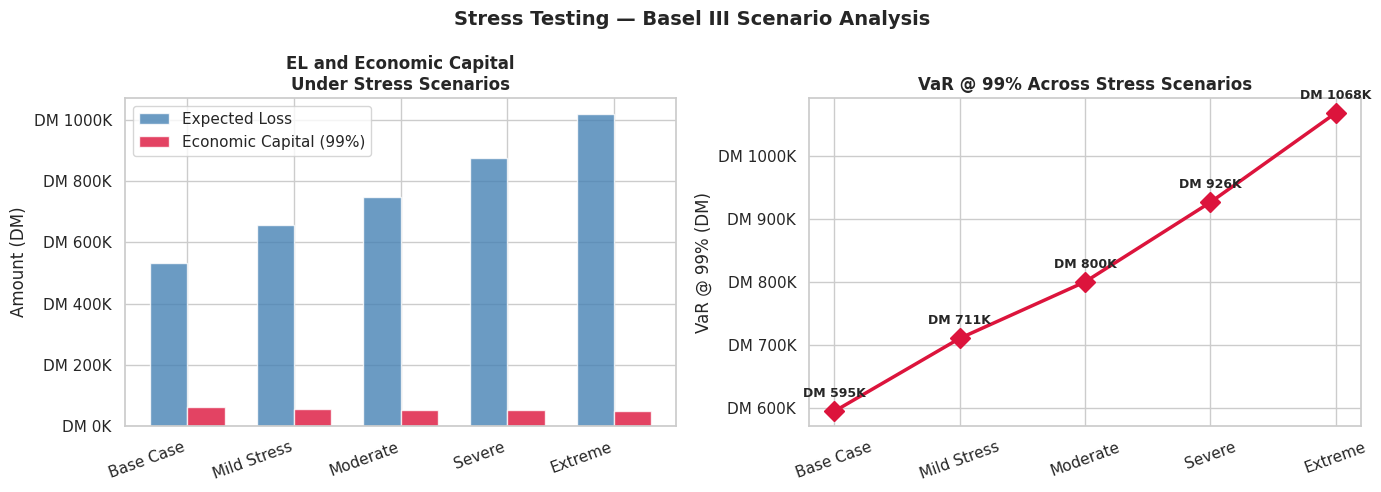

In [11]:
scenarios = {
    'Base Case'  : 1.0,    # current PDs
    'Mild Stress': 1.25,   # PDs +25%
    'Moderate'   : 1.50,   # PDs +50%
    'Severe'     : 2.00,   # PDs doubled
    'Extreme'    : 3.00    # PDs tripled
}

stress_results = []

for scenario_name, pd_multiplier in scenarios.items():
    stressed_pd  = np.clip(pd_arr * pd_multiplier, 0, 1)
    u_draws      = np.random.uniform(0, 1, size=(N_SIMULATIONS, n_loans))
    def_matrix   = (u_draws < stressed_pd).astype(float)
    lgd_mat      = np.random.beta(lgd_alpha, lgd_beta, size=(N_SIMULATIONS, n_loans))
    loss_mat     = def_matrix * lgd_mat * ead_arr
    port_loss    = loss_mat.sum(axis=1)

    el_s  = port_loss.mean()
    v95_s = np.percentile(port_loss, 95)
    v99_s = np.percentile(port_loss, 99)

    stress_results.append({
        'Scenario'   : scenario_name,
        'PD Mult'    : f'{pd_multiplier:.0%}',
        'Mean PD'    : f'{stressed_pd.mean()*100:.1f}%',
        'EL (DM)'    : round(el_s),
        'VaR 95%'    : round(v95_s),
        'VaR 99%'    : round(v99_s),
        'EC 99%'     : round(v99_s - el_s),
        'EL % Port'  : f'{el_s/total_exposure*100:.2f}%'
    })

stress_df = pd.DataFrame(stress_results)

print('=== Stress Test Results ===')
print(stress_df.to_string(index=False))

# Plot stress test results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(stress_df))
width = 0.35

axes[0].bar([i - width/2 for i in x], stress_df['EL (DM)'],
            width, label='Expected Loss', color='steelblue', alpha=0.8)
axes[0].bar([i + width/2 for i in x], stress_df['EC 99%'],
            width, label='Economic Capital (99%)', color='crimson', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(stress_df['Scenario'], rotation=20, ha='right')
axes[0].set_ylabel('Amount (DM)')
axes[0].set_title('EL and Economic Capital\nUnder Stress Scenarios', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'DM {v/1000:.0f}K'))
axes[0].legend()

axes[1].plot(stress_df['Scenario'], stress_df['VaR 99%'], 'D-',
             color='crimson', linewidth=2.5, markersize=10)
for i, row in stress_df.iterrows():
    axes[1].annotate(f"DM {row['VaR 99%']/1000:.0f}K",
                     (row['Scenario'], row['VaR 99%']),
                     textcoords='offset points', xytext=(0,10),
                     ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylabel('VaR @ 99% (DM)')
axes[1].set_title('VaR @ 99% Across Stress Scenarios', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'DM {v/1000:.0f}K'))
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Stress Testing — Basel III Scenario Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10 Business Impact Section

This is what **impresses interviewers the most** — translating model output into business decisions.

In [12]:
# Simulate impact of tightening credit policy
# What if we reject all applicants with PD > threshold?

pd_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]
policy_results = []

for thresh in pd_thresholds:
    approved = portfolio[portfolio['PD'] <= thresh]
    rejected = portfolio[portfolio['PD'] >  thresh]

    if len(approved) == 0:
        continue

    # Simulate EL for approved portfolio
    pd_appr   = approved['PD'].values
    ead_appr  = approved['EAD'].values
    u_draws   = np.random.uniform(0, 1, size=(N_SIMULATIONS, len(approved)))
    def_mat   = (u_draws < pd_appr).astype(float)
    lgd_mat   = np.random.beta(lgd_alpha, lgd_beta,
                               size=(N_SIMULATIONS, len(approved)))
    port_loss = (def_mat * lgd_mat * ead_appr).sum(axis=1)

    policy_results.append({
        'PD Threshold'    : f'{thresh*100:.0f}%',
        'Approved Loans'  : len(approved),
        'Rejected Loans'  : len(rejected),
        'Approval Rate'   : f'{len(approved)/len(portfolio)*100:.1f}%',
        'Approved EAD'    : round(approved['EAD'].sum()),
        'EL (simulated)'  : round(port_loss.mean()),
        'VaR 99%'         : round(np.percentile(port_loss, 99)),
        'EL Reduction %'  : f'{(1 - port_loss.mean()/el_simulated)*100:.1f}%'
    })

policy_df = pd.DataFrame(policy_results)

print('=== Credit Policy Analysis ===')
print('Question: How much does tightening approval criteria reduce expected losses?')
print()
print(policy_df.to_string(index=False))

print(f'\n Business Insight:')
if len(policy_df) >= 2:
    row_tight = policy_df[policy_df['PD Threshold']=='20%']
    if not row_tight.empty:
        el_reduction = row_tight['EL Reduction %'].values[0]
        approval_rate = row_tight['Approval Rate'].values[0]
        print(f'   Rejecting applicants with PD > 20% reduces expected losses by {el_reduction}')
        print(f'   while maintaining a {approval_rate} approval rate.')
        print(f'   This is the credit policy tradeoff banks make daily.')

=== Credit Policy Analysis ===
Question: How much does tightening approval criteria reduce expected losses?

PD Threshold  Approved Loans  Rejected Loans Approval Rate  Approved EAD  EL (simulated)  VaR 99% EL Reduction %
         10%             279             721         27.9%        709691           16757    31405          96.9%
         20%             471             529         47.1%       1250605           53534    78175          90.0%
         30%             587             413         58.7%       1634434           95744   129557          82.0%
         40%             682             318         68.2%       1916772          138598   177012          74.0%
         50%             769             231         76.9%       2230115          203160   248602          61.9%

 Business Insight:
   Rejecting applicants with PD > 20% reduces expected losses by 90.0%
   while maintaining a 47.1% approval rate.
   This is the credit policy tradeoff banks make daily.


## 11 Final Portfolio Risk Dashboard

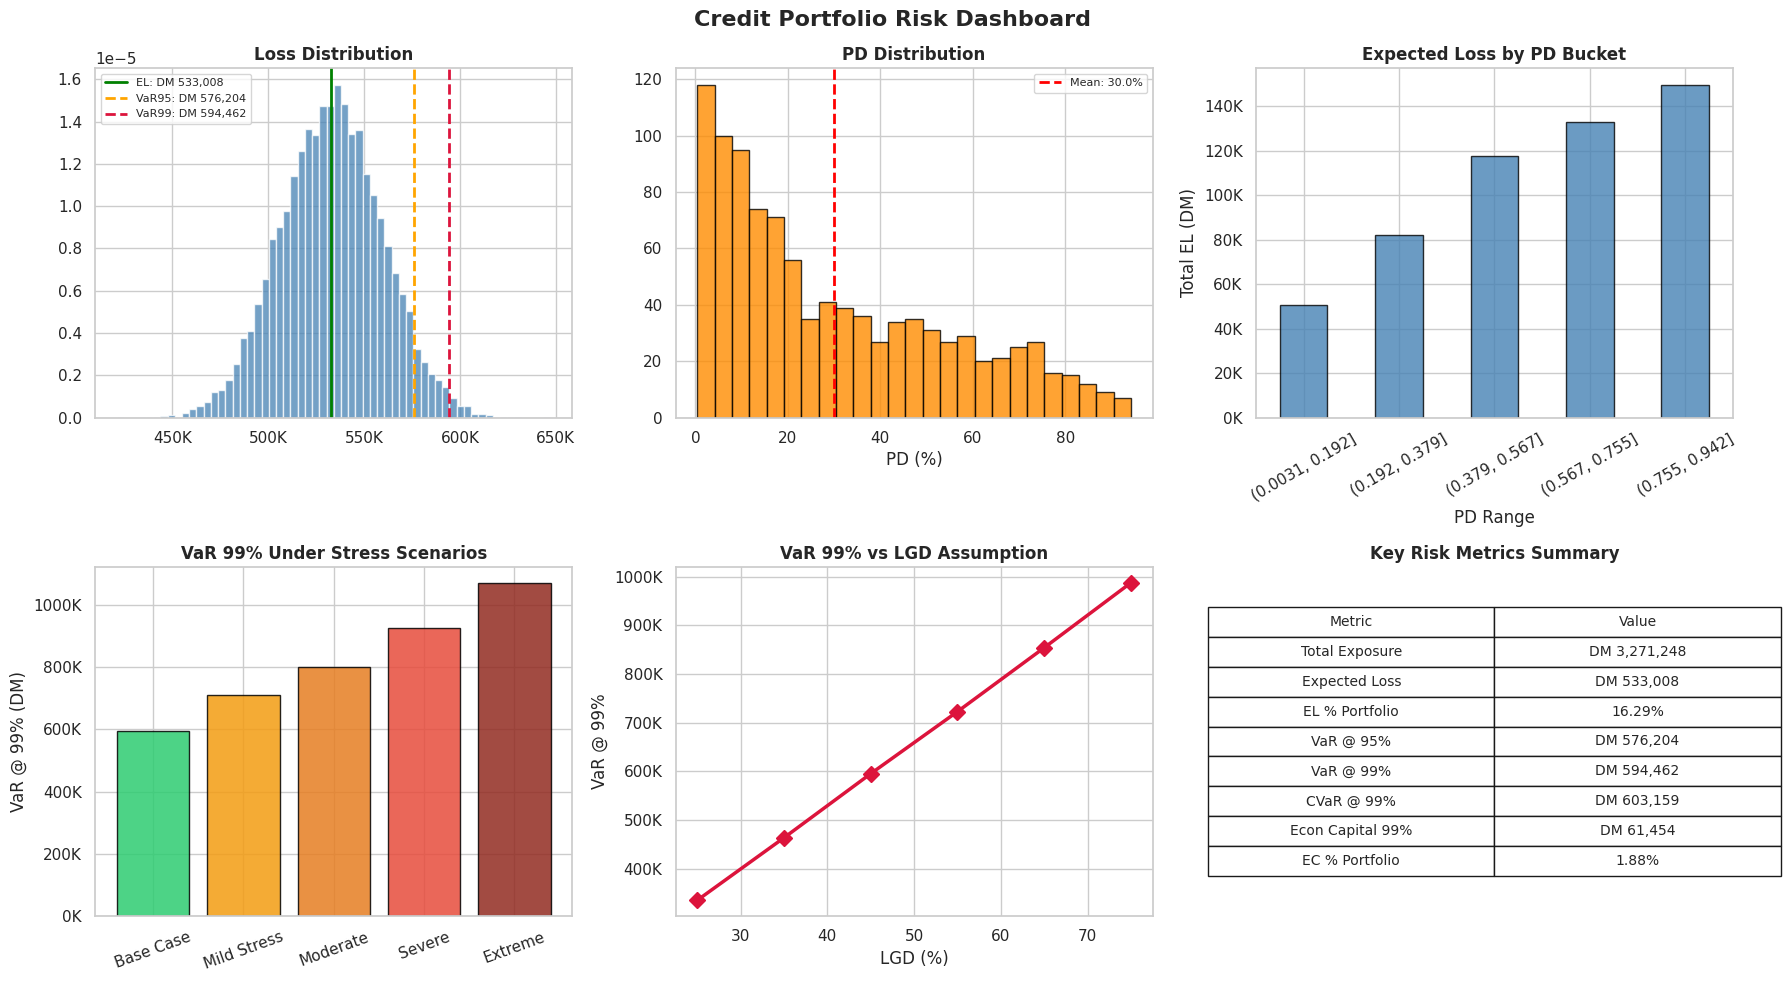

In [13]:
fig = plt.figure(figsize=(18, 10))

# ── Top left: Loss distribution ────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(portfolio_losses, bins=60, color='steelblue', alpha=0.75, density=True)
ax1.axvline(el_simulated, color='green',  linewidth=2, linestyle='-',  label=f'EL: DM {el_simulated:,.0f}')
ax1.axvline(var_95,       color='orange', linewidth=2, linestyle='--', label=f'VaR95: DM {var_95:,.0f}')
ax1.axvline(var_99,       color='crimson',linewidth=2, linestyle='--', label=f'VaR99: DM {var_99:,.0f}')
ax1.set_title('Loss Distribution', fontweight='bold')
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# ── Top middle: PD distribution ────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(portfolio['PD']*100, bins=25, color='darkorange', alpha=0.8, edgecolor='black')
ax2.axvline(portfolio['PD'].mean()*100, color='red', linestyle='--',
            linewidth=2, label=f'Mean: {portfolio["PD"].mean()*100:.1f}%')
ax2.set_title('PD Distribution', fontweight='bold')
ax2.set_xlabel('PD (%)')
ax2.legend(fontsize=8)

# ── Top right: EL by PD bucket ─────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
portfolio['pd_bucket'] = pd.cut(portfolio['PD'], bins=5)
el_by_bucket = portfolio.groupby('pd_bucket', observed=True)['EL'].sum()
el_by_bucket.plot(kind='bar', ax=ax3, color='steelblue', edgecolor='black', alpha=0.8)
ax3.set_title('Expected Loss by PD Bucket', fontweight='bold')
ax3.set_xlabel('PD Range')
ax3.set_ylabel('Total EL (DM)')
ax3.tick_params(axis='x', rotation=30)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# ── Bottom left: Stress test VaR ───────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
colors_stress = ['#2ecc71','#f39c12','#e67e22','#e74c3c','#922b21']
ax4.bar(stress_df['Scenario'], stress_df['VaR 99%'],
        color=colors_stress, edgecolor='black', alpha=0.85)
ax4.set_title('VaR 99% Under Stress Scenarios', fontweight='bold')
ax4.set_ylabel('VaR @ 99% (DM)')
ax4.tick_params(axis='x', rotation=20)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))

# ── Bottom middle: LGD sensitivity ─────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(sens_df['LGD']*100, sens_df['VaR_99'], 'D-', color='crimson',
         linewidth=2.5, markersize=8)
ax5.set_title('VaR 99% vs LGD Assumption', fontweight='bold')
ax5.set_xlabel('LGD (%)')
ax5.set_ylabel('VaR @ 99%')
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))

# ── Bottom right: Key metrics table ────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
metrics_table = [
    ['Metric', 'Value'],
    ['Total Exposure',   f'DM {total_exposure:,.0f}'],
    ['Expected Loss',    f'DM {el_simulated:,.0f}'],
    ['EL % Portfolio',   f'{el_simulated/total_exposure*100:.2f}%'],
    ['VaR @ 95%',        f'DM {var_95:,.0f}'],
    ['VaR @ 99%',        f'DM {var_99:,.0f}'],
    ['CVaR @ 99%',       f'DM {cvar_99:,.0f}'],
    ['Econ Capital 99%', f'DM {ec_99:,.0f}'],
    ['EC % Portfolio',   f'{ec_99/total_exposure*100:.2f}%'],
]
tbl = ax6.table(cellText=metrics_table[1:], colLabels=metrics_table[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
ax6.set_title('Key Risk Metrics Summary', fontweight='bold')

plt.suptitle('Credit Portfolio Risk Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 12 Save Results

In [14]:
# Save portfolio with risk metrics
portfolio.drop(columns=['pd_bucket'], errors='ignore').to_csv(
    'portfolio_risk.csv', index=False)

# Save summary metrics
summary = {
    'total_exposure': total_exposure,
    'expected_loss' : el_simulated,
    'el_pct'        : el_simulated/total_exposure,
    'var_95'        : var_95,
    'var_99'        : var_99,
    'cvar_99'       : cvar_99,
    'economic_capital_99': ec_99,
    'n_simulations' : N_SIMULATIONS
}
pd.Series(summary).to_csv('risk_summary.csv', header=False)

print('portfolio_risk.csv saved ')

print('risk_summary.csv saved ')

portfolio_risk.csv saved 
risk_summary.csv saved 


##  Key Interview Talking Points

**On the EL framework:**  
*"Expected Loss = PD × LGD × EAD is the foundation of Basel II credit risk capital calculations. I estimated PD from our logistic regression model, used 45% LGD as the Basel II standard for unsecured retail loans, and EAD as the outstanding loan balance."*

**On Monte Carlo vs analytical:**  
*"I used Monte Carlo instead of the analytical Vasicek model because it makes fewer assumptions, handles portfolio heterogeneity naturally, and allows stochastic LGD — which is more realistic. The cost is computational, but 10,000 simulations is manageable."*

**On VaR vs CVaR:**  
*"VaR tells you the loss threshold at a given confidence level. CVaR — also called Expected Shortfall — tells you the average loss given that you're already in the tail. CVaR is a more coherent risk measure and is preferred under Basel III and FRTB."*

**On stress testing:**  
*"Basel III requires banks to run stress tests under adverse macroeconomic scenarios. I simulated recession scenarios by multiplying PDs by stress factors — this shows how much additional capital the bank needs to hold under each scenario."*

**On the business impact section:**  
*"The model is only useful if it changes decisions. I showed that rejecting applicants with PD above 20% reduces expected losses significantly while maintaining a reasonable approval rate — that's the kind of business reasoning that matters to risk management teams."*

---
**Next Phase:** Streamlit App — deploy everything as an interactive risk calculator 